# Reproducibility of the HKAN paper

## Step 0: prepare environment

In [1]:
import os
import time
import numpy as np
import pandas as pd
import evaluation_metrics as em
import matplotlib.pyplot as plt
from scipy.stats import iqr
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

from hkan.hkan_original import (
    ExpandingLayer, ConnectingLayer,
    make_hkan_layer, extend_hkan,
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    set_tqdm_disable,
)
import visualize

random_seed = 0
np.random.seed(random_seed)

In [2]:
def load_dataset(dataset_prefix: str):
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## Step 1: Define building hkan model functions

In [3]:
def fit_hkan_layer(
        X, y, layer, n_vars_out,
        n_basis=15, centers="random_data_points", basis_fn=Sigmoid(s=8),
        expanding_base_regressor=None, connecting_base_regressor=None):
    """
    Fit one HKAN layer: ExpandingLayer (-> phi) then ConnectingLayer (-> h).
    """
    print(f"Layer: {layer}")
    # Edge base regression for each dimension (Block functions)
    # Expand each dimension by n_basis, apply centers, then apply regressor
    # If regressor is none, then the default is Linear regression
    expand = ExpandingLayer(
        n_vars_out=n_vars_out, n_basis=n_basis, centers=centers, basis_fn=basis_fn,
        base_regressor=expanding_base_regressor,
    )
    expand.fit(X, y)
    phi = expand.transform(X)

    # Neuron level regression for each neuron
    # Solve num_layers times regressio
    connect = ConnectingLayer(base_regressor=connecting_base_regressor)
    connect.fit(phi, y)

    # single-output (final) layer uses predict(); multi-output layers use transform()
    if n_vars_out > 1:
        h = connect.transform(phi)
    else:
        h = connect.predict(phi).reshape(-1, 1)

    return phi, h, expand, connect

def stack_hkan_layers(X_train, y_train, layer_configs):
    """
    Chain multiple fit_hkan_layer() calls to build an L-layer HKAN.
    """
    X_current = X_train
    stages = []

    # feed each layer's h-function output as the next layer's input
    for i, cfg in enumerate(layer_configs, start=1):
        phi, h, _, _ = fit_hkan_layer(X_current, y_train, **cfg)
        stages.append((i, phi, h))
        X_current = h   # next layer's input is this layer's output

    yhat = stages[-1][2].ravel()   # final layer's h, flattened to 1D
    return stages, yhat

In [4]:
# Quick test
phi, h, expand, connect = fit_hkan_layer(
    tf1_x_train, tf1_y_train, layer=0, n_vars_out=932, n_basis=2,
    centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1))
print(f"Shape of phi: {phi.shape}")
print(f"Shape of h: {h.shape}")

Layer: 0
Shape of phi: (932, 2, 5000)
Shape of h: (5000, 932)


In [5]:
def build_hkan_model_from_configs(model_configs, tqdm_disable=False):
    """
    Build an HKAN model from a list of layer-parameter dictionaries.
    
    Stacks layers sequentially, starting with layer 0 and extending upward.
    Each layer can have different basis functions, number of basis, centers, and regressors.

    Returns:
        HKAN model: Constructed multi-layer HKAN model ready for training
    """
    # Sort parameters by layer index to ensure correct order
    params = sorted(model_configs, key=lambda p: int(p["layer"]))
    model = None
    set_tqdm_disable(tqdm_disable)

    for p in params:
        layer_idx = int(p["layer"])
        n_vars_out = p["n_vars_out"]
        basis_fn = p["basis_fn"]
        n_basis = p.get("n_basis", 10)
        centers = p.get("centers", "random")
        expanding_base_regressor = p.get("expanding_base_regressor", None)
        connecting_base_regressor = p.get("connecting_base_regressor", None)


        if layer_idx == 0:
            # Create first layer with specified parameters
            model = make_hkan_layer(
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=expanding_base_regressor,
                connecting_base_regressor=connecting_base_regressor
            )
        else:
            # Stack additional layers on top of existing model
            if model is None:
                raise ValueError("First layer (layer 0) must be provided before extending.")
            model = extend_hkan(
                model,
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=expanding_base_regressor,
                connecting_base_regressor=connecting_base_regressor
            )
    return model

def fit_hkan(model, X_train, y_train):
    """
    Train an HKAN model on training data.
    
    Measures and reports training time.

    Args:
        model: HKAN model instance (from build_hkan_from_params)
        X_train (numpy array): Training input features
        y_train (numpy array): Training target labels

    Returns:
        None (model is trained in-place)
    """
    if model is not None:
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        print(f"\n✓ HKAN training completed in {elapsed_time:.4f} seconds")

def predict_hkan(model, X_test):
    """
    Make predictions with a trained HKAN model.
    
    Measures and reports prediction time.

    Args:
        model: Trained HKAN model instance
        X_test (numpy array): Test input features

    Returns:
        numpy array: Predictions on test data
    """
    if model is not None:
        start_time = time.time()
        predictions = model.predict(X_test)
        elapsed_time = time.time() - start_time
        print(f"✓ HKAN prediction completed in {elapsed_time:.4f} seconds")
        return predictions

def create_export_seed_results(seed_results, name):
    rows = []
    for i, r in enumerate(seed_results):
        rows.append({
            "seed": i,
            "train_mae": r["train"]["mae"],
            "train_rmse": r["train"]["rmse"],
            "train_inference_time_secs": r["train"]["inference_time_secs"],
            "test_mae": r["test"]["mae"],
            "test_rmse": r["test"]["rmse"],
            "test_inference_time_secs": r["test"]["inference_time_secs"],
        })

    seed_results_df = pd.DataFrame(rows)
    seed_results_df.to_csv(f"hkan/data/{name}.csv", index=False)
    return seed_results_df

def summarize_metrics(df, name):
    summary = {
        "model": name,
        "train_rmse_median": df["train_rmse"].median(),
        "train_rmse_iqr": iqr(df["train_rmse"]),
        "test_rmse_median": df["test_rmse"].median(),
        "test_rmse_iqr": iqr(df["test_rmse"]),
    }
    return summary

def run_hkan_seed_experiments(x_train, y_train, x_test, y_test, layer_configs, n_runs=50):
    """
    Train an HKAN model n_runs times (different random seed each run) and
    collect evaluation results for each run.
    """
    n_runs_results = []
    for s in range(n_runs):
        print(f"Seed: {s}")
        np.random.seed(s)

        model = build_hkan_model_from_configs(layer_configs, tqdm_disable=True)
        fit_hkan(model, x_train, y_train)

        results = em.evaluate(model, x_train, y_train, x_test, y_test)
        n_runs_results.append(results)

    return n_runs_results

## TF1

In [6]:
tf1_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

tf1_hkan_stages, tf1_ytrain_hat = stack_hkan_layers(tf1_x_train, tf1_y_train, tf1_layer_configs)
print("TF1 train R2:", r2_score(tf1_y_train, tf1_ytrain_hat))
print("TF1 train RMSE:", em.compute_rmse(tf1_ytrain_hat, tf1_y_train).item())

Layer: 0
Layer: 1
TF1 train R2: 1.0
TF1 train RMSE: 1.735641412395107e-11


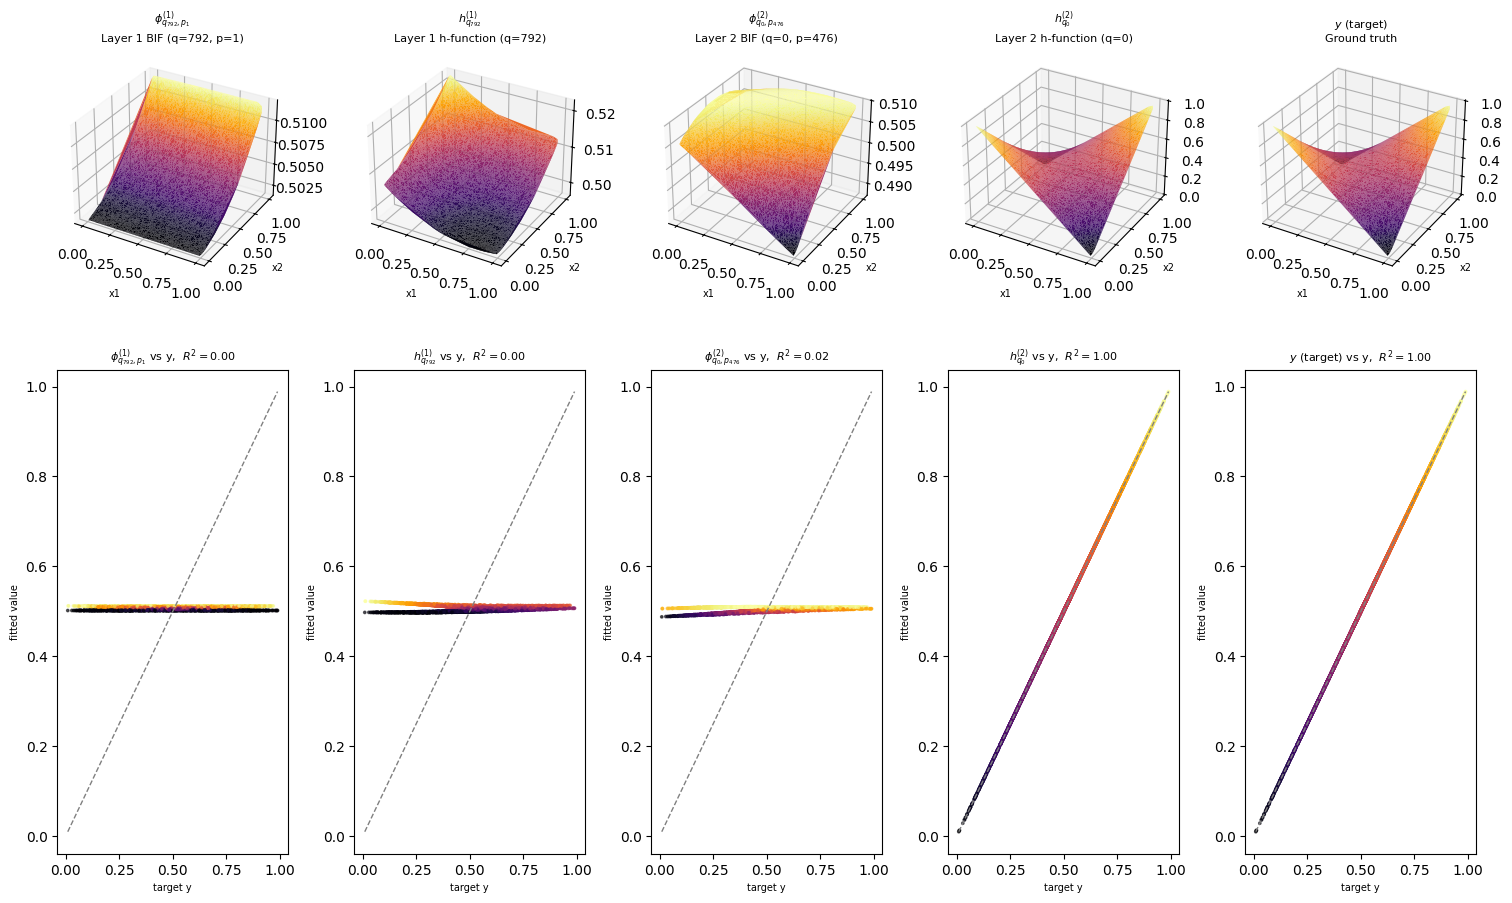

In [7]:
visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_hkan_stages, block_idx="random", seed=0)

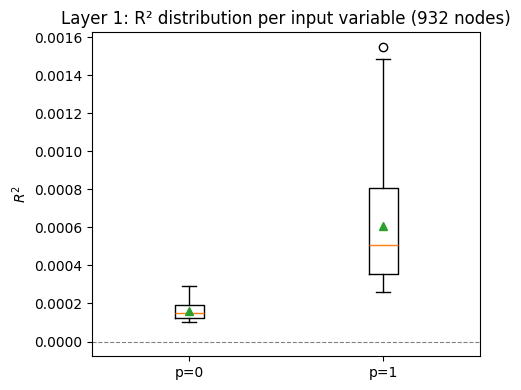

In [8]:
visualize.plot_first_layer_featurewise_r2_summary(tf1_hkan_stages, tf1_y_train)

In [9]:
tf1_hkan_model = build_hkan_model_from_configs(tf1_layer_configs)
fit_hkan(tf1_hkan_model, tf1_x_train, tf1_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


✓ HKAN training completed in 3.8934 seconds


In [10]:
predict_hkan(tf1_hkan_model, tf1_x_test)

✓ HKAN prediction completed in 2.4698 seconds


array([1.        , 0.98989899, 0.97979798, ..., 0.97979798, 0.98989899,
       1.        ])

In [11]:
tf1_hkan_results = em.evaluate(tf1_hkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
em.print_results(tf1_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.279979e-11         1.486749e-11        
RMSE            1.710471e-11         2.688307e-11        
-------------------------------------------------------
Inference (s)   1.433579             3.066396            


In [12]:
# # Run hkan for different seeds
# tf1_n_runs_results = run_hkan_seed_experiments(
#     tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, tf1_layer_configs, n_runs=50)
# # Create and export df
# tf1_n_runs_df = create_export_seed_results(tf1_n_runs_results, "tf1_50_run_results")
# # Calculate median and IQR
# tf1_summary = summarize_metrics(tf1_n_runs_df, "TF1 HKAN")
# tf1_summary

In [13]:
tf1_n_runs_df = pd.read_csv("hkan/data/tf1_50_run_results.csv")
tf1_n_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,1.512566e-11,2.024243e-11,4.314514,1.707880e-11,2.528154e-11,3.156479
1,1,1.344724e-11,1.812655e-11,2.387029,1.569419e-11,2.994677e-11,3.532666
2,2,1.256730e-11,1.668564e-11,2.092398,1.444941e-11,2.382730e-11,3.016004
3,3,1.812613e-11,2.463908e-11,1.379149,2.123946e-11,3.599102e-11,2.425109
4,4,1.055642e-11,1.426535e-11,1.198433,1.199046e-11,1.894674e-11,2.123505


In [14]:
tf1_summary = summarize_metrics(tf1_n_runs_df, "TF1 HKAN")
tf1_summary

{'model': 'TF1 HKAN',
 'train_rmse_median': 1.5767214228132815e-11,
 'train_rmse_iqr': 3.908054711691378e-12,
 'test_rmse_median': 2.2646640551961518e-11,
 'test_rmse_iqr': 6.0379549511298735e-12}

## TF2

In [15]:
tf2_layer_configs = [
    dict(layer=0, n_vars_out=48, n_basis=17, centers="random", basis_fn=Tanh(s=22), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=11, n_basis=21, centers="random_data_points", basis_fn=Softplus(s=18), expanding_base_regressor=Ridge(alpha=1)),
    dict(layer=2, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [16]:
tf2_hkan_stages, tf2_ytrain_hat = stack_hkan_layers(tf2_x_train, tf2_y_train, tf2_layer_configs)
print("TF2 train R2:", r2_score(tf2_y_train, tf2_ytrain_hat))
print("TF2 train RMSE:", em.compute_rmse(tf2_ytrain_hat, tf2_y_train).item())

Layer: 0


Fitting connecting regressors: 100%|██████████| 48/48 [00:00<00:00, 1453.28it/s]


Layer: 1


Fitting connecting regressors: 100%|██████████| 11/11 [00:00<00:00, 154.29it/s]


Layer: 2


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 417.34it/s]

TF2 train R2: 0.5518207899727806
TF2 train RMSE: 0.11622109356116267


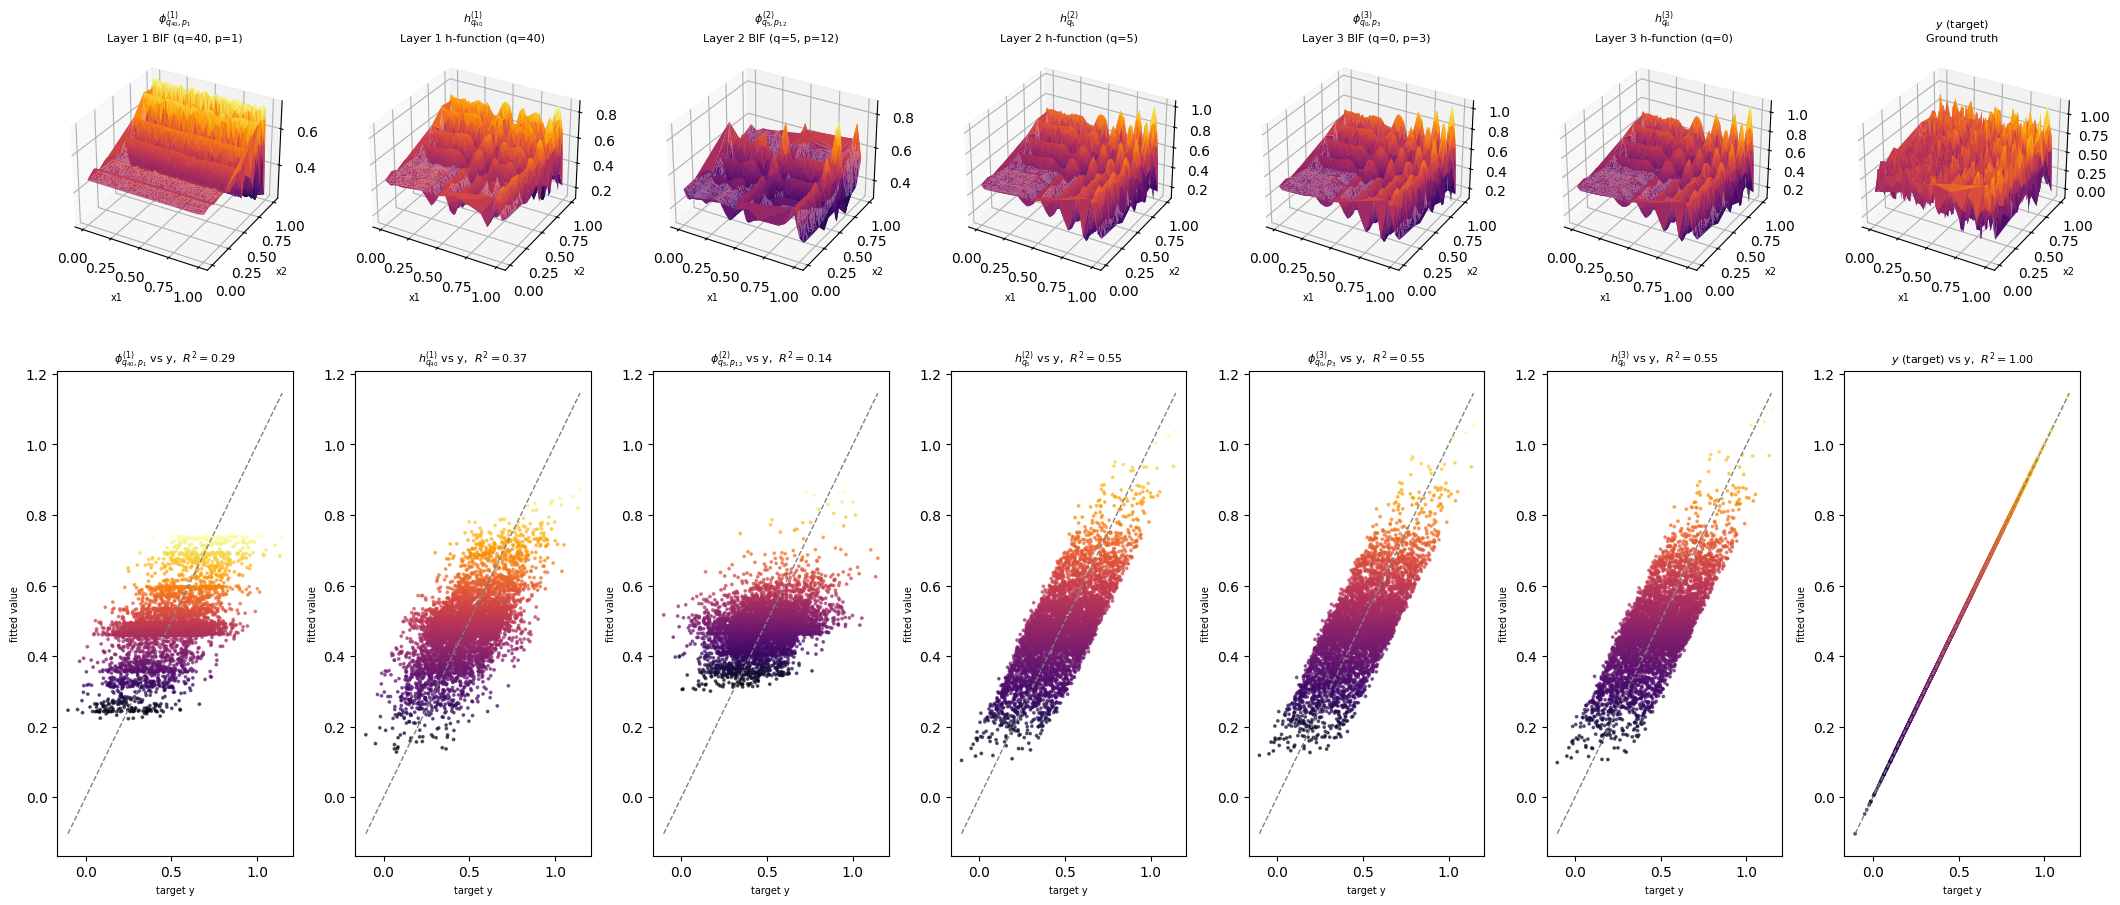

In [17]:
visualize.plot_model_stages(tf2_x_train, tf2_y_train, tf2_hkan_stages, block_idx="random", seed=0)

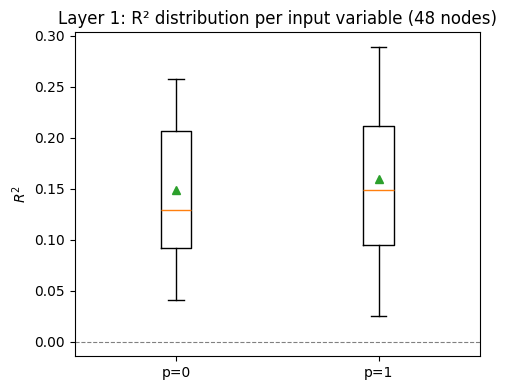

In [18]:
visualize.plot_first_layer_featurewise_r2_summary(tf2_hkan_stages, tf2_y_train)

In [19]:
tf2_hkan_model = build_hkan_model_from_configs(tf2_layer_configs)
fit_hkan(tf2_hkan_model, tf2_x_train, tf2_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 461.93it/s]


✓ HKAN training completed in 2.3007 seconds


In [20]:
predict_hkan(tf2_hkan_model, tf2_x_test)

✓ HKAN prediction completed in 1.9098 seconds


array([0.51269147, 0.50270795, 0.49508579, ..., 0.32440484, 0.21583844,
       0.1482147 ])

In [21]:
tf2_hkan_results = em.evaluate(tf2_hkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
em.print_results(tf2_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.007820e-01         1.194852e-02        
RMSE            1.163169e-01         1.573088e-02        
-------------------------------------------------------
Inference (s)   1.014966             1.897022            


In [22]:
# # Run hkan for different seeds
# tf2_n_runs_results = run_hkan_seed_experiments(
#     tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, tf2_layer_configs, n_runs=50)
# # Create and export df
# tf2_n_runs_df = create_export_seed_results(tf2_n_runs_results, "tf2_50_run_results")
# # Calculate median and IQR
# tf2_summary = summarize_metrics(tf2_n_runs_df, "TF2 HKAN")
# tf2_summary

In [23]:
tf2_n_runs_df = pd.read_csv("hkan/data/tf2_50_run_results.csv")
tf2_n_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.100710,0.116169,0.944310,0.011829,0.015740,1.731554
1,1,0.100849,0.116314,1.015722,0.011959,0.015793,1.807327
2,2,0.100704,0.116143,0.952415,0.011746,0.015548,1.846159
3,3,0.100661,0.116141,0.969792,0.012359,0.015942,1.676831
4,4,0.100781,0.116354,0.974512,0.012188,0.016042,1.768053


In [24]:
tf2_summary = summarize_metrics(tf2_n_runs_df, "TF2 HKAN")
tf2_summary

{'model': 'TF2 HKAN',
 'train_rmse_median': 0.1162740277033517,
 'train_rmse_iqr': 0.0001500757657232482,
 'test_rmse_median': 0.01646540377539695,
 'test_rmse_iqr': 0.0011648351390373991}

## TF3

In [25]:
tf3_layer_configs = [
    dict(layer=0, n_vars_out=924, n_basis=39, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.001)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [26]:
tf3_hkan_stages, tf3_ytrain_hat = stack_hkan_layers(tf3_x_train, tf3_y_train, tf3_layer_configs)
print("TF3 train R2:", r2_score(tf3_y_train, tf3_ytrain_hat))
print("TF3 train RMSE:", em.compute_rmse(tf3_ytrain_hat, tf3_y_train).item())

Layer: 0


Fitting connecting regressors: 100%|██████████| 924/924 [00:00<00:00, 2776.12it/s]


Layer: 1


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  4.21it/s]

TF3 train R2: 0.9999999966185914
TF3 train RMSE: 9.363546475329145e-06


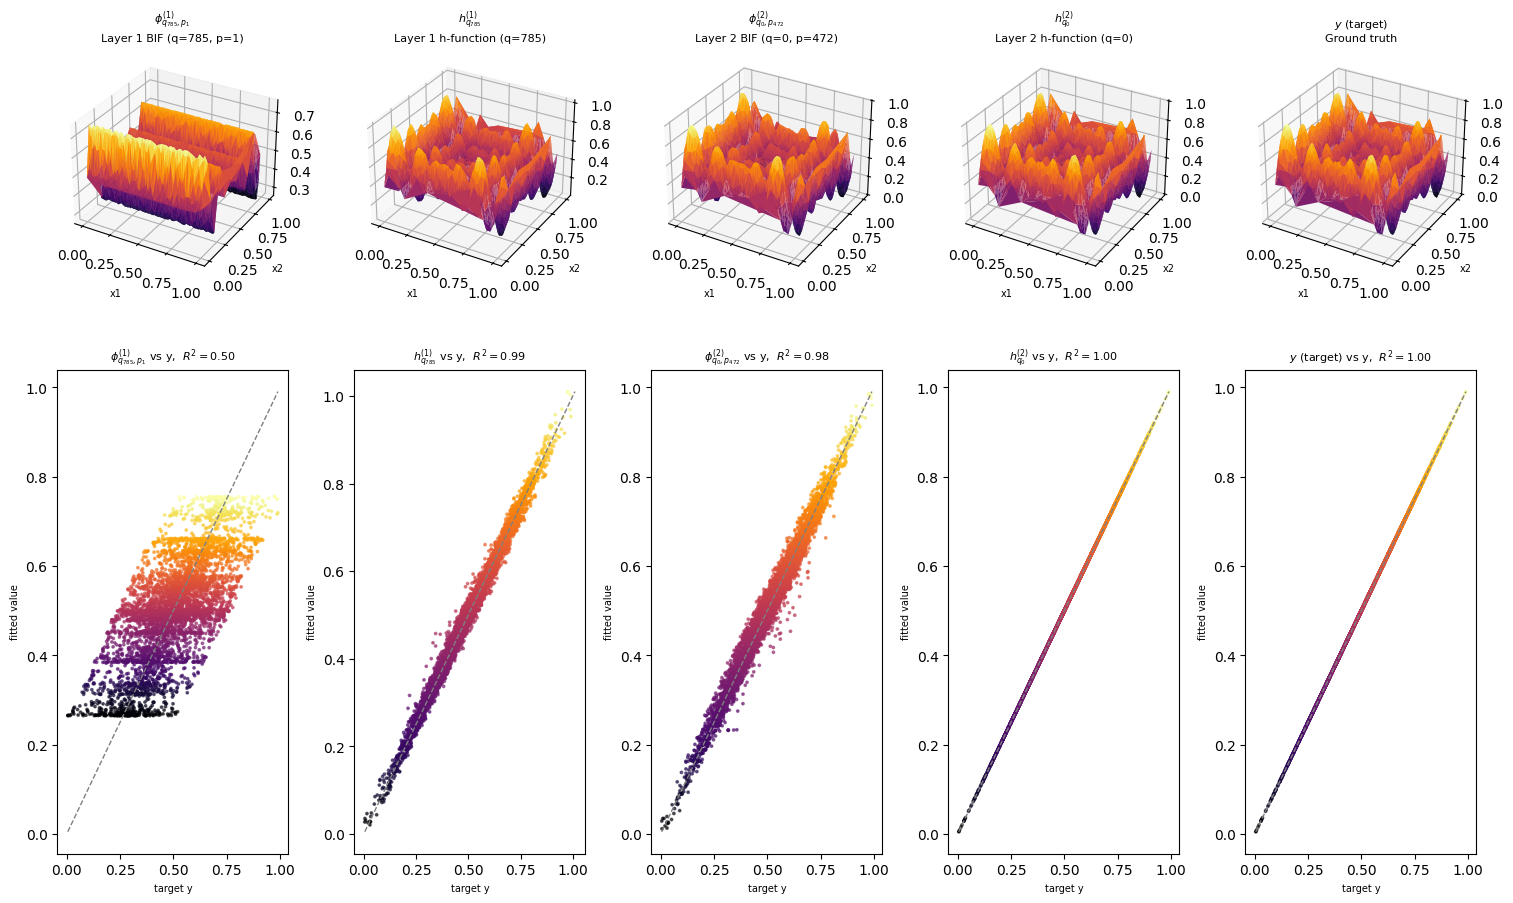

In [27]:
visualize.plot_model_stages(tf3_x_train, tf3_y_train, tf3_hkan_stages, block_idx="random", seed=0)

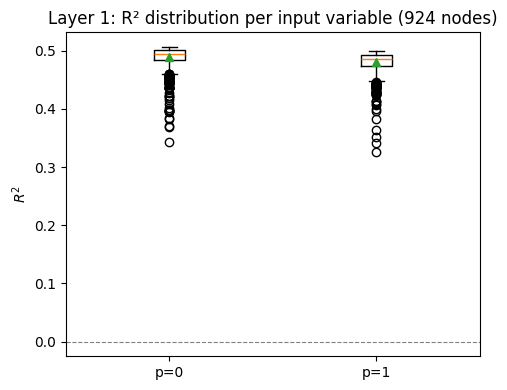

In [28]:
visualize.plot_first_layer_featurewise_r2_summary(tf3_hkan_stages, tf3_y_train)

In [29]:
tf3_hkan_model = build_hkan_model_from_configs(tf3_layer_configs)
fit_hkan(tf3_hkan_model, tf3_x_train, tf3_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  4.01it/s]


✓ HKAN training completed in 13.8186 seconds


In [30]:
predict_hkan(tf3_hkan_model, tf3_x_test)

✓ HKAN prediction completed in 9.1673 seconds


array([0.2843032 , 0.35059164, 0.4170099 , ..., 0.58299007, 0.64940618,
       0.71570441])

In [31]:
tf3_hkan_results = em.evaluate(tf3_hkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
em.print_results(tf3_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.757543e-06         3.739552e-06        
RMSE            9.340102e-06         6.216287e-06        
-------------------------------------------------------
Inference (s)   6.896625             9.218750            


In [32]:
# # Run hkan for different seeds
# tf3_n_runs_results = run_hkan_seed_experiments(
#     tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, tf3_layer_configs, n_runs=50)
# # Create and export df
# tf3_n_runs_df = create_export_seed_results(tf3_n_runs_results, "tf3_50_run_results")
# # Calculate median and IQR
# tf3_summary = summarize_metrics(tf3_n_runs_df, "TF3 HKAN")
# tf3_summary

In [33]:
tf3_n_runs_df = pd.read_csv("hkan/data/tf3_50_run_results.csv")
tf3_n_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.000004,0.000009,3.347555,0.000004,0.000006,7.013773
1,1,0.000004,0.000009,3.464386,0.000004,0.000007,7.113740
2,2,0.000004,0.000009,3.549067,0.000004,0.000006,6.916375
3,3,0.000004,0.000009,3.418817,0.000004,0.000006,7.520968
4,4,0.000004,0.000009,3.749339,0.000004,0.000006,8.543746


In [34]:
tf3_summary = summarize_metrics(tf3_n_runs_df, "TF3 HKAN")
tf3_summary

{'model': 'TF3 HKAN',
 'train_rmse_median': 9.331330334421612e-06,
 'train_rmse_iqr': 7.890196262366223e-08,
 'test_rmse_median': 6.2224607190262305e-06,
 'test_rmse_iqr': 3.016883838600043e-07}

## TF4

In [35]:
tf4_layer_configs = [
    dict(layer=0, n_vars_out=1, n_basis=2, centers="equally_spaced", basis_fn=Tanh(s=3), expanding_base_regressor=Ridge(alpha=0.001)),
]

In [36]:
tf4_hkan_stages, tf4_ytrain_hat = stack_hkan_layers(tf4_x_train, tf4_y_train, tf4_layer_configs)
print("TF4 train R2:", r2_score(tf4_y_train, tf4_ytrain_hat))
print("TF4 train RMSE:", em.compute_rmse(tf4_ytrain_hat, tf4_y_train).item())

Layer: 0


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 508.59it/s]

TF4 train R2: 0.02834862824367934
TF4 train RMSE: 0.2594232852239973


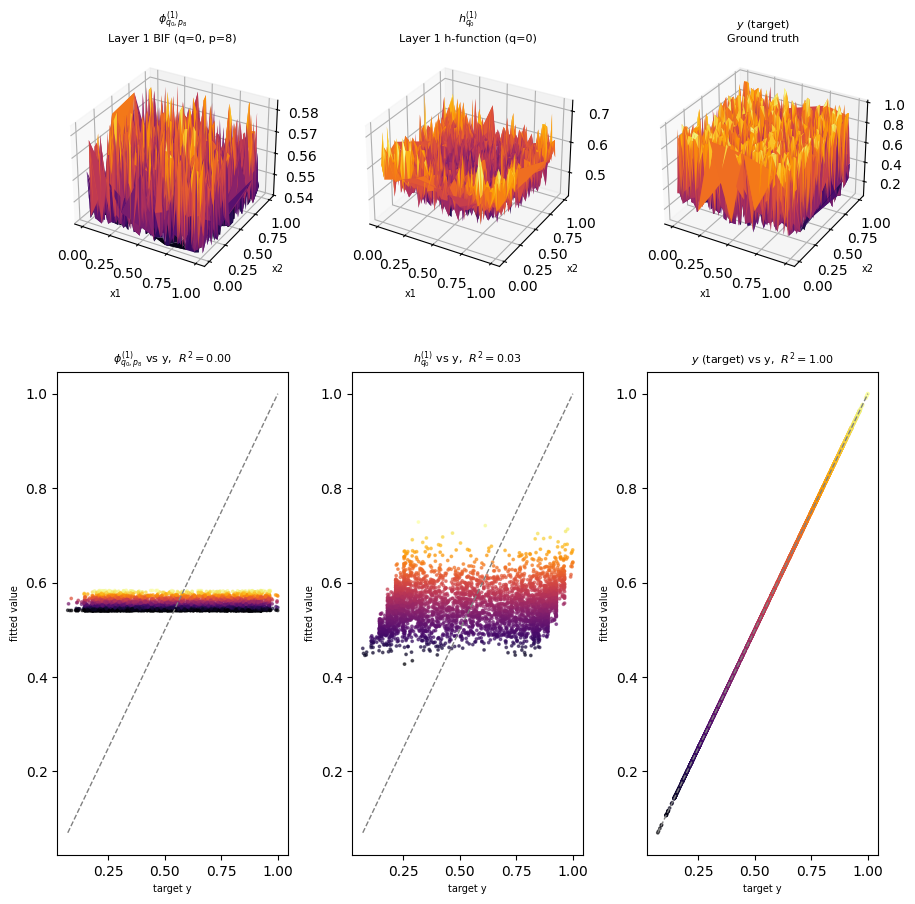

In [37]:
visualize.plot_model_stages(tf4_x_train, tf4_y_train, tf4_hkan_stages, block_idx="random", seed=0)

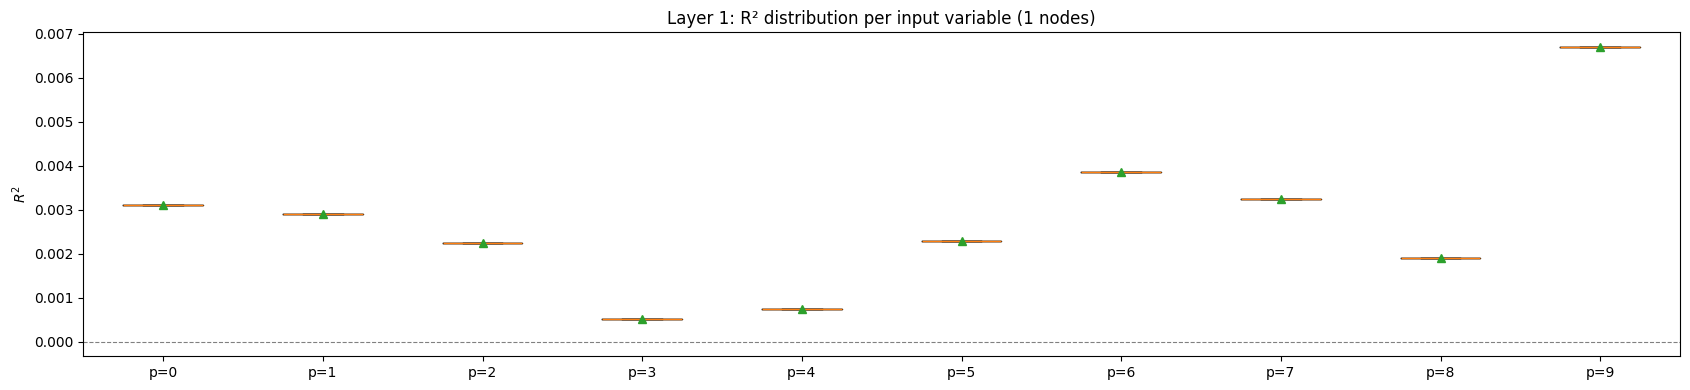

In [38]:
visualize.plot_first_layer_featurewise_r2_summary(tf4_hkan_stages, tf4_y_train)

In [39]:
tf4_hkan_model = build_hkan_model_from_configs(tf4_layer_configs)
fit_hkan(tf4_hkan_model, tf4_x_train, tf4_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 1004.86it/s]


✓ HKAN training completed in 0.0092 seconds


In [40]:
predict_hkan(tf4_hkan_model, tf4_x_test)

✓ HKAN prediction completed in 0.0025 seconds


array([0.58666128, 0.49008735, 0.62895011, ..., 0.50647657, 0.6278018 ,
       0.50546087])

In [41]:
tf4_hkan_results = em.evaluate(tf4_hkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
em.print_results(tf4_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.338550e-01         2.323804e-01        
RMSE            2.594233e-01         2.584713e-01        
-------------------------------------------------------
Inference (s)   0.006496             0.001367            


In [42]:
# # Run hkan for different seeds
# tf4_n_runs_results = run_hkan_seed_experiments(
#     tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, tf4_layer_configs, n_runs=50)
# # Create and export df
# tf4_n_runs_df = create_export_seed_results(tf4_n_runs_results, "tf4_50_run_results")
# # Calculate median and IQR
# tf4_summary = summarize_metrics(tf4_n_runs_df, "TF4 HKAN")
# tf4_summary

In [43]:
tf4_n_runs_df = pd.read_csv("hkan/data/tf4_50_run_results.csv")
tf4_n_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.233855,0.259423,0.004388,0.23238,0.258471,0.001331
1,1,0.233855,0.259423,0.003752,0.23238,0.258471,0.000799
2,2,0.233855,0.259423,0.002433,0.23238,0.258471,0.000776
3,3,0.233855,0.259423,0.001568,0.23238,0.258471,0.000510
4,4,0.233855,0.259423,0.003493,0.23238,0.258471,0.000506


In [44]:
tf4_summary = summarize_metrics(tf4_n_runs_df, "TF4 HKAN")
tf4_summary

{'model': 'TF4 HKAN',
 'train_rmse_median': 0.2594232852239973,
 'train_rmse_iqr': 0.0,
 'test_rmse_median': 0.2584713405613519,
 'test_rmse_iqr': 0.0}

## TF5

In [45]:
tf5_layer_configs = [
    dict(layer=0, n_vars_out=912, n_basis=23, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.01)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [46]:
tf5_hkan_stages, tf5_ytrain_hat = stack_hkan_layers(tf5_x_train, tf5_y_train, tf5_layer_configs)
print("TF5 train R2:", r2_score(tf5_y_train, tf5_ytrain_hat))
print("TF5 train RMSE:", em.compute_rmse(tf5_ytrain_hat, tf5_y_train).item())

Layer: 0


Fitting connecting regressors: 100%|██████████| 912/912 [00:00<00:00, 2569.17it/s]


Layer: 1


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  4.61it/s]

TF5 train R2: 1.0
TF5 train RMSE: 3.1099935037452305e-13


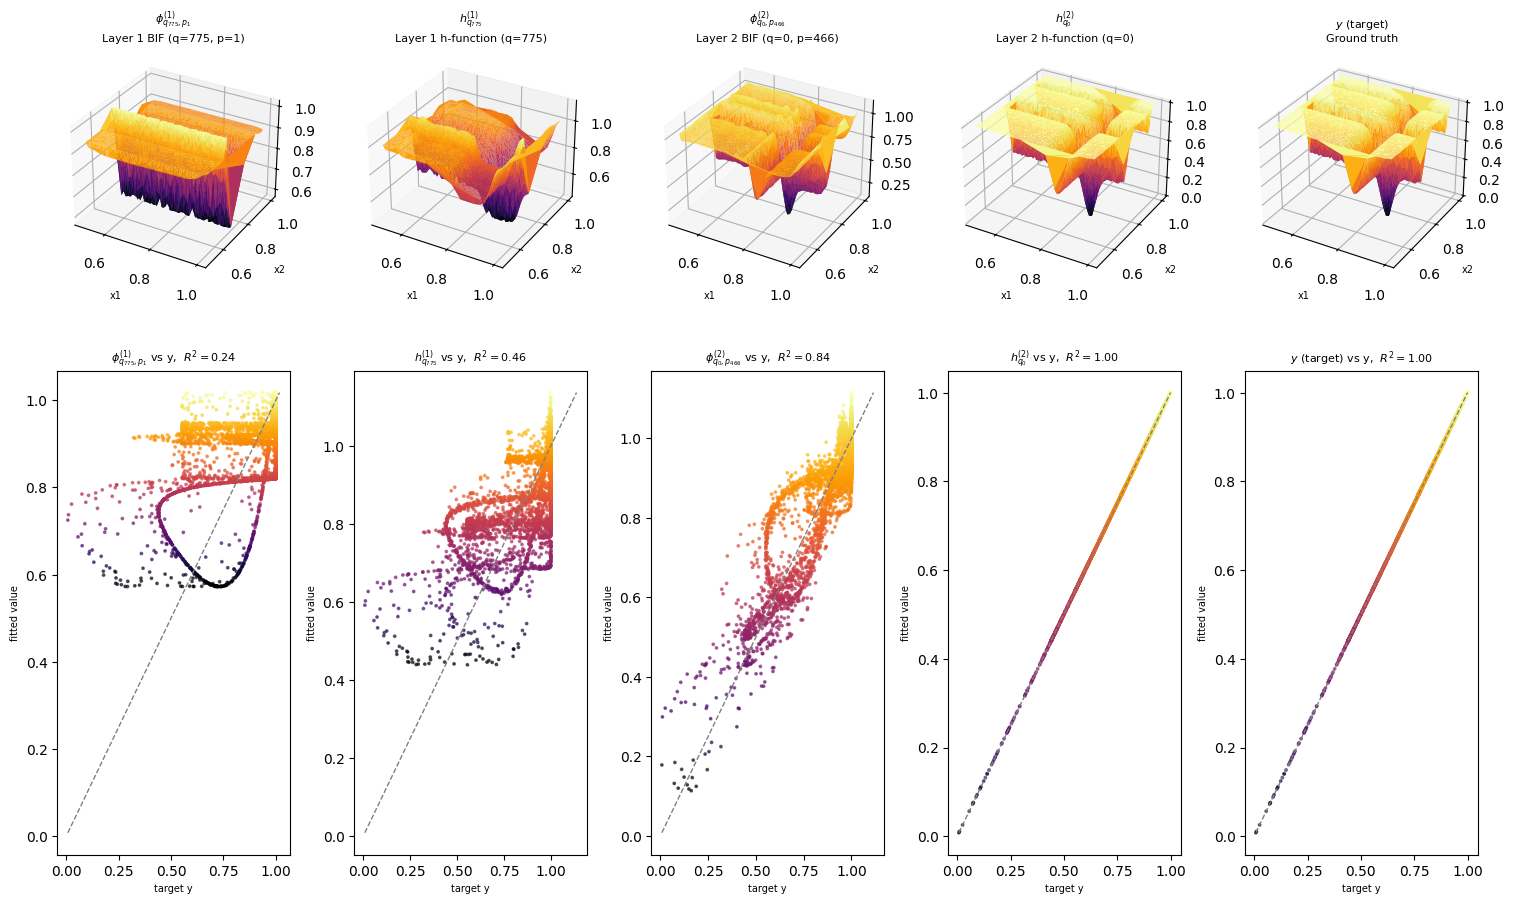

In [47]:
visualize.plot_model_stages(tf5_x_train, tf5_y_train, tf5_hkan_stages, block_idx="random", seed=0)

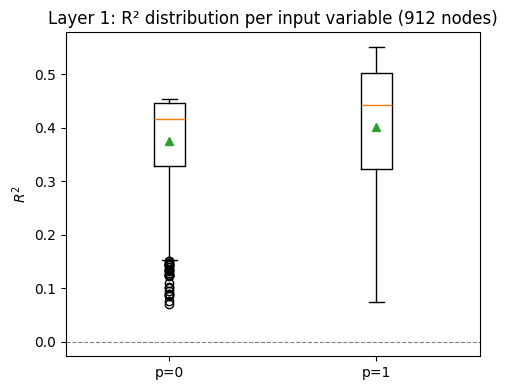

In [48]:
visualize.plot_first_layer_featurewise_r2_summary(tf5_hkan_stages, tf5_y_train)

In [49]:
tf5_hkan_model = build_hkan_model_from_configs(tf5_layer_configs)
fit_hkan(tf5_hkan_model, tf5_x_train, tf5_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  4.76it/s]


✓ HKAN training completed in 6.3776 seconds


In [50]:
predict_hkan(tf5_hkan_model, tf5_x_test)

✓ HKAN prediction completed in 4.1116 seconds


array([1., 1., 1., ..., 1., 1., 1.])

In [51]:
tf5_hkan_results = em.evaluate(tf5_hkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
em.print_results(tf5_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.320268e-13         1.702152e-13        
RMSE            1.616858e-13         2.800322e-13        
-------------------------------------------------------
Inference (s)   2.239795             4.052426            


In [1]:
# # Run hkan for different seeds
# tf5_n_runs_results = run_hkan_seed_experiments(
#     tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, tf5_layer_configs, n_runs=50)
# # Create and export df
# tf5_n_runs_df = create_export_seed_results(tf5_n_runs_results, "tf5_50_run_results")
# # Calculate median and IQR
# tf5_summary = summarize_metrics(tf5_n_runs_df, "TF5 HKAN")
# tf5_summary

In [53]:
tf5_n_runs_df = pd.read_csv("hkan/data/tf5_50_run_results.csv")
tf5_n_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,2.332798e-13,2.957596e-13,2.915268,2.480856e-13,3.175458e-13,5.796774
1,1,1.662814e-13,2.049143e-13,2.225703,2.149076e-13,3.887162e-13,5.553694
2,2,1.468826e-13,1.878652e-13,2.444690,2.091421e-13,5.338536e-13,3.776449
3,3,1.495048e-13,1.922386e-13,2.256234,2.266363e-13,5.136188e-13,4.005617
4,4,1.603455e-13,1.984997e-13,2.125601,2.079142e-13,3.668583e-13,4.010567


In [54]:
tf5_summary = summarize_metrics(tf5_n_runs_df, "TF5 HKAN")
tf5_summary

{'model': 'TF5 HKAN',
 'train_rmse_median': 2.240970868666831e-13,
 'train_rmse_iqr': 7.142021180771875e-14,
 'test_rmse_median': 3.8901535501829135e-13,
 'test_rmse_iqr': 2.1262966416959008e-13}